# 03 Application: Dynamic Value-at-Risk

This notebook connects the volatility forecasting models to a practical risk-management application. The main goal is to compare a model-based dynamic VaR against a rolling historical VaR benchmark.

Main workflow:

1. Load saved volatility forecasts and SPY return data  
2. Construct dynamic parametric VaR estimates  
3. Compute rolling historical VaR benchmark  
4. Compare VaR forecasts with realized returns  
5. Evaluate violation frequency and risk calibration

## 1. Import packages and project utilities

The notebook uses reusable helper functions from `src/` to keep the workflow modular and reproducible.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.var import compute_dynamic_var, compute_rolling_var
from src.evaluation import evaluate

## 2. Load processed data

We load the processed modeling dataset and SPY return series generated in `01_data_setup.ipynb`. The same time-ordered 80/20 train-test split is reused so that the VaR evaluation period aligns with the volatility forecasting test period.


In [3]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / "model_data.csv", index_col=0, parse_dates=True)
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)

feature_cols = ["vol_lag1", "vol_lag5", "vol_lag10", "vol_lag21"]
X = df[feature_cols]
y = df["target"]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

test_returns = returns["SPY"].loc[y_test.index]

df.head()


,vol,vol_lag1,vol_lag5,vol_lag10,vol_lag21,target
Date,,,,,,
2015-03-05,0.076596,0.088954,0.117697,0.138447,0.178846,0.092105
2015-03-06,0.092105,0.076596,0.106632,0.138762,0.167061,0.086748
2015-03-09,0.086748,0.092105,0.104768,0.130694,0.165993,0.104233
2015-03-10,0.104233,0.086748,0.092912,0.128510,0.161693,0.103366
2015-03-11,0.103366,0.104233,0.088954,0.128742,0.150427,0.106206


## 3. Load volatility forecasts

If `model_predictions.csv` already exists from `02_modeling.ipynb`, we load the saved out-of-sample volatility forecasts directly. This keeps the VaR application notebook lightweight and ensures consistency with the forecasting results generated in the modeling stage.

In [4]:
pred_path = DATA_DIR / "model_predictions.csv"

predictions = pd.read_csv(pred_path, index_col=0, parse_dates=True)

pred_vol = predictions["stacking"].loc[y_test.index]

## 4. Dynamic VaR using predicted volatility

The dynamic VaR uses the model-predicted annualized volatility and converts it into a daily volatility estimate. A 5% VaR threshold is then computed using the standard normal quantile.


In [5]:
var_dynamic_5 = compute_dynamic_var(pred_vol, alpha=0.05)
violations_dynamic = test_returns < var_dynamic_5

dynamic_violation_rate = violations_dynamic.mean()

dynamic_summary = pd.DataFrame({
    "Metric": ["Expected Violation Rate", "Actual Violation Rate", "Number of Violations"],
    "Value": [0.05, dynamic_violation_rate, int(violations_dynamic.sum())]
})

dynamic_summary


,Metric,Value
0,Expected Violation Rate,0.050000
1,Actual Violation Rate,0.062626
2,Number of Violations,31.000000


## 5. Rolling historical VaR benchmark

The benchmark VaR is based on a 21-day rolling standard deviation of SPY daily returns. Unlike the model-based VaR approach, the rolling historical benchmark relies only on recent realized volatility and does not incorporate machine learning forecasts.

In [6]:
var_benchmark_5 = compute_rolling_var(test_returns, window=21, alpha=0.05).dropna()

common_index = var_benchmark_5.index.intersection(var_dynamic_5.index)

test_returns_common = test_returns.loc[common_index]
var_dynamic_common = var_dynamic_5.loc[common_index]
var_benchmark_common = var_benchmark_5.loc[common_index]

violations_dynamic_common = test_returns_common < var_dynamic_common
violations_benchmark_common = test_returns_common < var_benchmark_common

dynamic_rate = violations_dynamic_common.mean()
benchmark_rate = violations_benchmark_common.mean()

comparison_var = pd.DataFrame({
    "Method": ["Dynamic VaR", "Rolling Historical VaR"],
    "Violation Rate": [dynamic_rate, benchmark_rate],
    "Distance from 5%": [abs(dynamic_rate - 0.05), abs(benchmark_rate - 0.05)],
    "Number of Violations": [
        int(violations_dynamic_common.sum()),
        int(violations_benchmark_common.sum())
    ]
})

comparison_var


,Method,Violation Rate,Distance from 5%,Number of Violations
0,Dynamic VaR,0.065263,0.015263,31
1,Rolling Historical VaR,0.052632,0.002632,25


## 6. Visualization of VaR breaches

We first evaluate how well the model captures volatility dynamics.


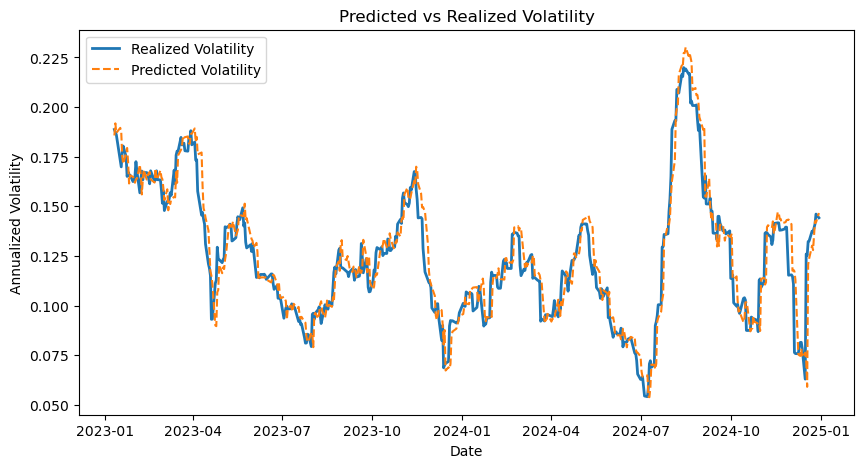

In [7]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Realized Volatility", linewidth=2)
plt.plot(pred_vol.index, pred_vol, label="Predicted Volatility", linestyle="--")

plt.title("Predicted vs Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.savefig(FIGURE_DIR / "volatility_forecast.png", dpi=300)
plt.show()

We then assess downstream risk performance by comparing the model-based Dynamic VaR against a rolling historical VaR benchmark.

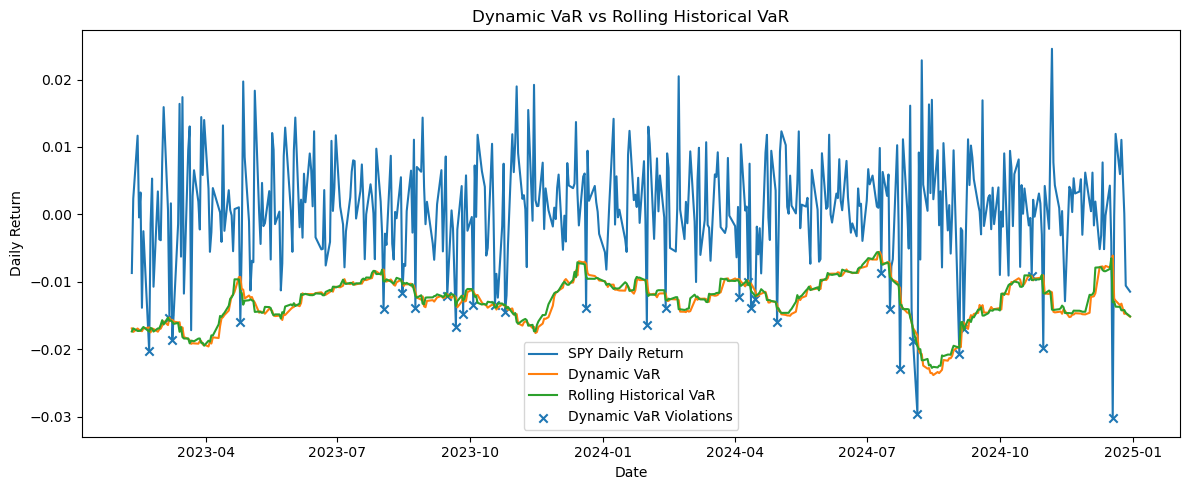

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(test_returns_common.index, test_returns_common, label="SPY Daily Return")
plt.plot(var_dynamic_common.index, var_dynamic_common, label="Dynamic VaR")
plt.plot(var_benchmark_common.index, var_benchmark_common, label="Rolling Historical VaR")

plt.scatter(
    test_returns_common.index[violations_dynamic_common],
    test_returns_common[violations_dynamic_common],
    marker="x",
    label="Dynamic VaR Violations"
)

plt.title("Dynamic VaR vs Rolling Historical VaR")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dynamic_var_vs_benchmark.png", dpi=300)
plt.show()


## 7. Interpretation

The dynamic VaR framework connects volatility forecasting to risk management. Instead of assuming a fixed or purely historical volatility level, the dynamic VaR adjusts over time based on the model's predicted volatility. A violation occurs when the realized return is lower than the VaR threshold.

The theoretical violation rate for a 5% VaR model is 5%. If the dynamic VaR violation rate is closer to 5% than the rolling historical VaR benchmark, this suggests that model-based volatility forecasts improve downside risk calibration. If the violation rate is much higher than 5%, the model underestimates tail risk; if it is much lower than 5%, the model is too conservative.

This application demonstrates how volatility forecasting can be integrated into a practical risk-management framework. Rather than evaluating models solely through RMSE or MAE, the forecasts are assessed based on their ability to improve downside risk measurement and VaR calibration. The model is no longer evaluated only by RMSE or MAE; it is also evaluated by whether it improves risk measurement in a realistic portfolio-risk setting.


## 8. Save final outputs

The comparison table and aligned VaR series are saved so they can be used in the README, report, or later strategy notebook.


In [9]:
comparison_var.to_csv(DATA_DIR / "var_comparison.csv", index=False)

var_output = pd.DataFrame({
    "SPY_Return": test_returns_common,
    "Dynamic_VaR_5": var_dynamic_common,
    "Rolling_Historical_VaR_5": var_benchmark_common,
    "Dynamic_Violation": violations_dynamic_common.astype(int),
    "Benchmark_Violation": violations_benchmark_common.astype(int)
})

var_output.to_csv(DATA_DIR / "var_backtest_series.csv")
var_output.head()


,SPY_Return,Dynamic_VaR_5,Rolling_Historical_VaR_5,Dynamic_Violation,Benchmark_Violation
Date,,,,,
2023-02-09,-0.008707,-0.016923,-0.017384,0,0
2023-02-10,0.002331,-0.017445,-0.016922,0,0
2023-02-13,0.011671,-0.016941,-0.017302,0,0
2023-02-14,-0.000460,-0.017137,-0.017304,0,0
2023-02-15,0.003242,-0.017263,-0.017261,0,0
